In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

C:\Users\rajna\AppData\Local\Temp\ipykernel_25020\1871147362.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun


In [2]:
api_wrapper = ArxivAPIWrapper(top_k_result=2,doc_content_char_max=500) 
arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
print(arxiv.name)

arxiv


In [8]:
!pip uninstall -y arxiv
!pip install "arxiv==1.4.8"


Found existing installation: arxiv 1.4.8
Uninstalling arxiv-1.4.8:
  Successfully uninstalled arxiv-1.4.8
  Using cached arxiv-1.4.8-py3-none-any.whl.metadata (8.1 kB)
Using cached arxiv-1.4.8-py3-none-any.whl (12 kB)


In [3]:
arxiv.invoke("Attention is all you need")

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=Attention+is+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=3)

In [4]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

# 1. Create the API wrapper with desired settings
api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)

# 2. Wrap it into a WikipediaQueryRun tool
wiki = WikipediaQueryRun(api_wrapper=api_wrapper)

# 3. Check name and invoke
print(wiki.name)
response = wiki.invoke("what is Machine Learning?")
print(response)


wikipedia
Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.
Statistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.
From 


In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [7]:
### custom funcation 
### Custom Functions

def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b


# This will be a tool

def add(a: int, b: int) -> int:
    """Adds a and b.
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a:int,b:int) ->float:
    """Divide a and b.
    Args:
        a: first int
        b: second int
    """
    return a/b
tools  = [arxiv,wiki,add,multiply,divide]

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults() 


C:\Users\rajna\AppData\Local\Temp\ipykernel_25020\4061353794.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke("Provide me the recent ai news for march 3rd 2026")

[{'title': 'AI Pulse, AI news made by AI. March 3, 2026',
  'url': 'https://www.youtube.com/watch?v=tbzqKY-rp3c',
  'content': 'whole thing looked opportunistic. It\'s two AI giants facing the exact same ethical dilemma and taking wildly different paths. And you know, while all this corporate drama and politics is happening, the real world impact is just devastating. According to Iranian state media, this is the number of people, a lot of them kids, killed in one single missile strike on a school. It\'s just a brutal reminder of the human cost when warfare gets accelerated by AI. So, you have to ask, what\'s powering these incredible and frankly terrifying new capabilities? Well, that takes us to the hardware. It\'s a whole new kind of arms race. So, get this. Nvidia, the undisputed king of AI chips, is making a massive and until now secret move. They\'re building a brand new type of processor. But it\'s not for training AI. It\'s for running it. And in doing so, they\'re trying to sol

In [11]:
tools  = [arxiv,wiki,tavily,add,multiply,divide]

In [20]:
import os
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))
for m in client.models.list().data:
    print(m.id)


meta-llama/llama-prompt-guard-2-22m
groq/compound-mini
openai/gpt-oss-safeguard-20b
whisper-large-v3
whisper-large-v3-turbo
canopylabs/orpheus-arabic-saudi
allam-2-7b
groq/compound
canopylabs/orpheus-v1-english
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-120b
qwen/qwen3.8-27b
openai/gpt-oss-20b


In [33]:
from langchain_groq import ChatGroq
llm =  ChatGroq(model="openai/gpt-oss-safeguard-20b")
llm_with_tools = llm.bind_tools(tools)


In [34]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

response = llm_with_tools.invoke([HumanMessage(content="What is the recent ai news")])
pprint(response)



AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer question: "What is the recent ai news". We need to browse for recent AI news. Use tavily_search_results_json. Let\'s search.', 'tool_calls': [{'id': 'fc_b6a64970-0cca-41da-9f89-2cc23e10b64d', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 405, 'total_tokens': 468, 'completion_time': 0.063644224, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.008221709, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.046602297, 'total_time': 0.071865933}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0c2ae-4cc6-72d2-a7e4-4190a00f3e2d-0', tool_calls=[{'name': 'tavily_search_results_

In [35]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

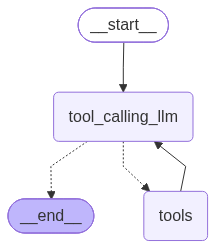

In [36]:
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Define State
class State(TypedDict):
    messages: Annotated[list, add_messages]

#### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

builder.add_edge(START, "tool_calling_llm") 
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

# View Mermaid Graph
display(Image(graph.get_graph().draw_mermaid_png()))


In [37]:
messages=graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

HTTPError: Page request resulted in HTTP 301: None (http://export.arxiv.org/api/query?search_query=&id_list=1706.03762&sortBy=relevance&sortOrder=descending&start=0&max_results=3)

In [38]:
messages=graph.invoke({"messages": HumanMessage(content="Provide me the top 10 recent AI news for March 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

Provide me the top 10 recent AI news for March 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_b9e47a00-cdee-4db8-bb2b-e2d3fa2cb30e)
 Call ID: fc_b9e47a00-cdee-4db8-bb2b-e2d3fa2cb30e
  Args:
    query: March 3 2025 AI news top 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 10 Biggest AI News Stories Of 2025", "url": "https://www.crn.com/news/ai/2025/the-10-biggest-ai-news-stories-of-2025", "content": "Google announcing in March its plan to buy Wiz for $32 billion to boost AI capabilities in its security product portfolio\n ServiceNow unveiling in March its plan to buy Moveworks for about $3 billion to boost its AI assistant abilities\n IBM disclosing earlier this month its plan to buy Confluent for $11 billion to aid in AI deployment 

# Agent Memory

In [39]:
messages=graph.invoke({"messages": HumanMessage(content="what is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (fc_8c80e3f2-015e-4e8d-a0a7-8592fed4e627)
 Call ID: fc_8c80e3f2-015e-4e8d-a0a7-8592fed4e627
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

13


In [40]:
messages=graph.invoke({"messages": HumanMessage(content="Divide that by 5 ")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5 
================================== Ai Message ==================================

I’m happy to divide a number for you, but I need to know which number you’d like to divide by 5. Could you let me know the value?


# MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [ ]:
## sepcify the therad



In [41]:
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Define State
class State(TypedDict):
    messages: Annotated[list, add_messages]

#### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools)) 

builder.add_edge(START, "tool_calling_llm") 
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")



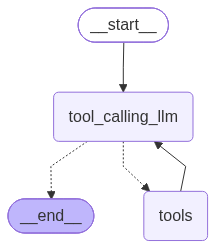

In [42]:

from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [43]:
## Specify the thread
config={"configurable":{"thread_id":"1"}}

In [46]:
## Specify the thread
config={"configurable":{"thread_id":"1"}}
# Specify an input
messages = [HumanMessage(content="Add 12 and 13.")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_1db60e73-deb7-410c-9683-f8c8463834fe)
 Call ID: fc_1db60e73-deb7-410c-9683-f8c8463834fe
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25


In [49]:
messages = [HumanMessage(content="divide the 5 ")]
messages=graph_memory.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (fc_1db60e73-deb7-410c-9683-f8c8463834fe)
 Call ID: fc_1db60e73-deb7-410c-9683-f8c8463834fe
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25
================================ Human Message =================================

divide the 5 
================================== Ai Message ==================================

I’m not sure what you’d like to divide the number 5 by. Could you let me know the second value (or the operation you have in mind)?
